# Principal Component Analysis Implementation (AY: 2025-26)

## Sarvesh Vikas Tikekar (2022120037)

# **Introduction to PCA**

PCA stands for **Principal Component Analysis** is a dimensionality reduction technique used in data analysis and machine learning.

It helps you to reduce the number of features in a dataset while keeping the most important information by changing your original features into new features, where these new features don’t overlap with each other and the first few keep most of the important differences found in the original data.

PCA is commonly used for data preprocessing for use with machine learning algorithms. It helps to remove redundancy, improve computational efficiency and make data easier to visualize and analyze especially when dealing with high-dimensional data.

For the implementation of this algorithm, we would be making use of the **Pima Indians Diabetes Database/Dataset** from Kaggle

*  Link to Dataset: [Pima Diabetes Dataset](https://www.kaggle.com/datasets/mathchi/diabetes-data-set)


In [103]:
# Going to our actual project directory
%cd /content/drive/MyDrive/CSL701-Machine-Learning/
!pwd

/content/drive/MyDrive/CSL701-Machine-Learning
/content/drive/MyDrive/CSL701-Machine-Learning


In [104]:
!pip3 install scikit-learn

# **About the Dataset**

The Diabetes Dataset (Pima Indians) on Kaggle is a well-known dataset used for predicting the onset of diabetes in female patients of Pima Indian heritage, aged 21 or older.

It contains 768 records and 9 columns, including 8 diagnostic features such as Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, and Age, with Outcome as the binary target variable indicating the presence (1) or absence (0) of diabetes.

This dataset is particularly suitable for classification tasks and for demonstrating data preprocessing, feature analysis, and predictive modeling.

The dataset is widely used in educational and research settings for tasks such as machine learning model building, feature engineering, and exploratory data analysis.

Overall, it provides a clean, structured tabular dataset ideal for testing classification algorithms and dimensionality reduction techniques like PCA.

In [105]:
# Importing all the libraries

import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from warnings import filterwarnings
from IPython.display import display, Math

filterwarnings("ignore")

In [106]:
# Declaring some global objects

std_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

In [107]:
data = pd.read_csv("Datasets/diabetes.csv")
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [108]:
data.shape

(768, 9)

<Axes: >

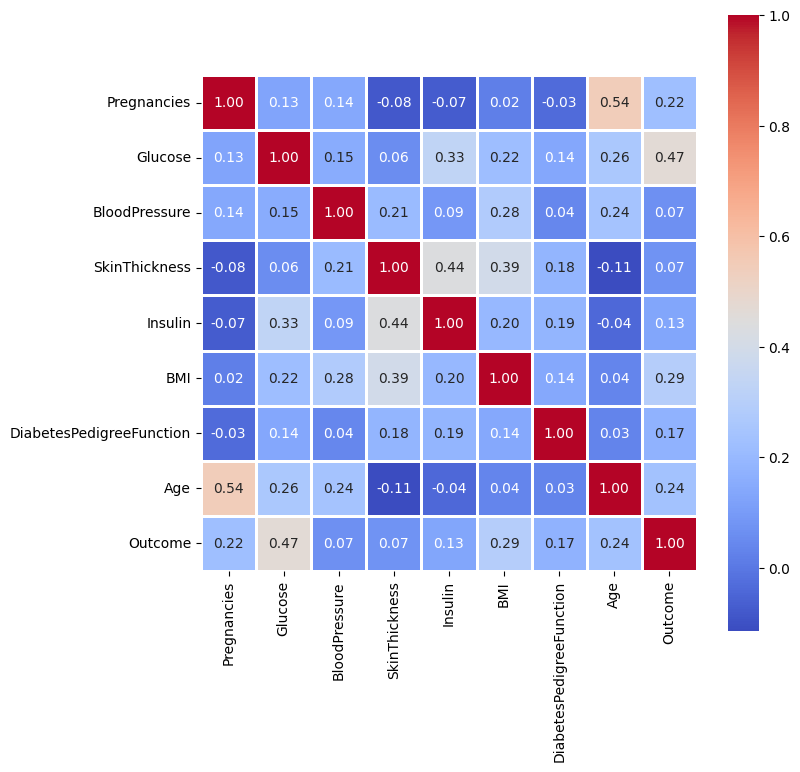

In [109]:
# Finding out the correlation matrix

plt.figure(figsize=(8, 8))
cor = data.corr()
sns.heatmap(data=cor, cmap="coolwarm", square = True , annot=True, linewidths=0.75, fmt='.2f')

In [110]:
#Check for missing values

data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# **Working of PCA Algorithm**

---

**Step 1**: Standardize the Data  
Different features may have different units and scales like salary vs. age. To compare them fairly PCA first standardizes the data by making each feature have:

**A mean of 0 and a standard deviation of 1.**

$$
Z = \frac{X - \mu}{\sigma}
$$

---

**Step 2**: Calculate Covariance Matrix  
Next PCA calculates the covariance matrix to see how features relate to each other whether they increase or decrease together. The covariance between two features is:

$$
\text{cov}(x_1, x_2) = \frac{\sum_{i=1}^{n} (x_{1i} - \bar{x}_1)(x_{2i} - \bar{x}_2)}{n-1}
$$

where **n** is the number of data points. The value of covariance can be positive, negative or zeros.

---

**Step 3**: Find the Principal Components  
PCA identifies new axes where the data spreads out the most:

- 1st Principal Component (PC1): The direction of maximum variance (most spread).  
- 2nd Principal Component (PC2): The next best direction, perpendicular to PC1 and so on.  

These directions come from the eigenvectors of the covariance matrix and their importance is measured by eigenvalues. For a square matrix A an eigenvector X (a non-zero vector) and its corresponding eigenvalue λ satisfy:

$$
A X = \lambda X
$$

This means:

- When A acts on X it only stretches or shrinks X by the scalar λ.  
- The direction of X remains unchanged hence eigenvectors define "stable directions" of A.  
- Eigenvalues help rank these directions by importance.

---

**Step 4**: Pick the Top Directions & Transform Data  
After calculating the eigenvalues and eigenvectors PCA ranks them by the amount of information they capture. We then:

- Select the top k components that capture most of the variance like 95%.  
- Transform the original dataset by projecting it onto these top components.  

This means we reduce the number of features (dimensions) while keeping the important patterns in the data.


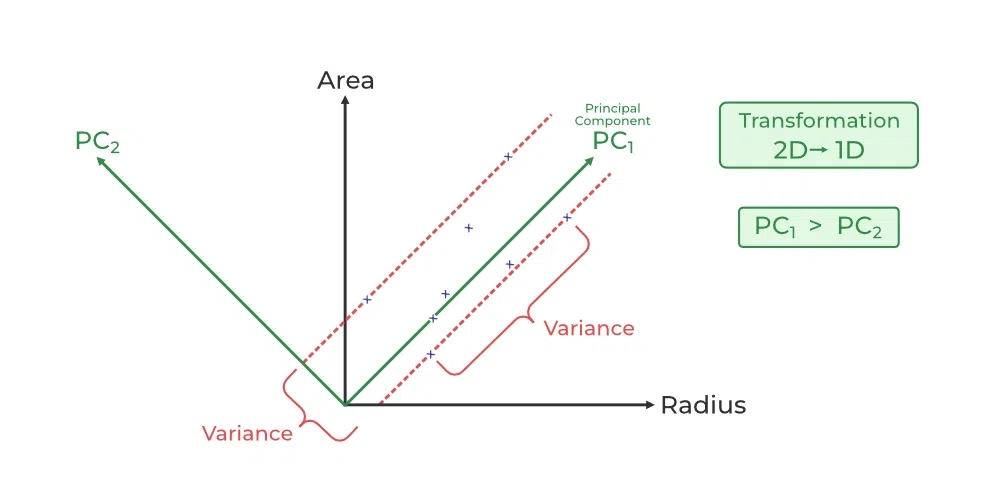


* These new axes are rotated versions of the original ones. PC₁ captures the maximum variance in the data meaning it holds the most information while PC₂ captures the remaining variance and is perpendicular to PC₁.

* The spread of data is much wider along PC₁ than along PC₂. This is why PC₁ is chosen for dimensionality reduction. By projecting the data points (blue crosses) onto PC₁ we effectively transform the 2D data into 1D and retain most of the important structure and patterns.

* Image Link: [Reference](https://media.geeksforgeeks.org/wp-content/uploads/20230420165431/Principal-Componenent-Analysisi.webp)

In [111]:
# Standardizing the data (First seperating the features and the class)

X = data.drop(columns=['Outcome'])
y = data['Outcome']

x_standarised = std_scaler.fit_transform(X)
x_normalised = min_max_scaler.fit_transform(X)

print(f"Standardized Data: \n {x_standarised}")
print(f"Normalised Data: \n {x_normalised}")
print()
print(f"Data shapes are: {x_standarised.shape} and {x_normalised.shape}")


Standardized Data: 
 [[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]
Normalised Data: 
 [[0.35294118 0.74371859 0.59016393 ... 0.50074516 0.23441503 0.48333333]
 [0.05882353 0.42713568 0.54098361 ... 0.39642325 0.11656704 0.16666667]
 [0.47058824 0.91959799 0.52459016 ... 0.34724292 0.25362938 0.18333333]
 ...
 [0.29411765 0.6080402  0.59016393 ... 0.390462   0.07130658 0.15      ]
 [0.05882353 0.63316583 0.49180328 ... 0.4485842  0.11571307 0.43333333]
 [0.05882353 0.46733668 0.57377049 ... 0.45305514 0.10119556 0.03333333]]

Data shapes are: (768, 

In [112]:
# Calculating the covariance matrix

X = x_standarised
cov_m = np.cov(X.T)

print(f"Covariance matrix is: \n {cov_m} \n and its shape is {cov_m.shape}")

Covariance matrix is: 
 [[ 1.00130378  0.12962746  0.14146618 -0.08177826 -0.07363049  0.01770615
  -0.03356638  0.54505093]
 [ 0.12962746  1.00130378  0.15278853  0.05740263  0.33178913  0.2213593
   0.13751636  0.26385788]
 [ 0.14146618  0.15278853  1.00130378  0.2076409   0.08904933  0.2821727
   0.04131875  0.23984024]
 [-0.08177826  0.05740263  0.2076409   1.00130378  0.43735204  0.39308503
   0.18416737 -0.11411885]
 [-0.07363049  0.33178913  0.08904933  0.43735204  1.00130378  0.19811702
   0.18531222 -0.04221793]
 [ 0.01770615  0.2213593   0.2821727   0.39308503  0.19811702  1.00130378
   0.14083033  0.03628912]
 [-0.03356638  0.13751636  0.04131875  0.18416737  0.18531222  0.14083033
   1.00130378  0.03360507]
 [ 0.54505093  0.26385788  0.23984024 -0.11411885 -0.04221793  0.03628912
   0.03360507  1.00130378]] 
 and its shape is (8, 8)


In [113]:
# Eigen value and vector Decomposition

eigen_values, eigen_vectors = np.linalg.eig(cov_m)
print("\nEigenvalues:\n", eigen_values)
print("\nEigenvectors (each column corresponds to an eigenvalue):\n", eigen_vectors)


Eigenvalues:
 [2.09711056 1.73346726 0.42036353 0.40498938 0.68351839 0.76333832
 0.87667054 1.03097228]

Eigenvectors (each column corresponds to an eigenvalue):
 [[-0.1284321  -0.59378583 -0.58879003  0.11784098 -0.19359817  0.47560573
  -0.08069115  0.01308692]
 [-0.39308257 -0.17402908 -0.06015291  0.45035526 -0.09416176 -0.46632804
   0.40432871 -0.46792282]
 [-0.36000261 -0.18389207 -0.19211793 -0.01129554  0.6341159  -0.32795306
  -0.05598649  0.53549442]
 [-0.43982428  0.33196534  0.28221253  0.5662838  -0.00958944  0.48786206
  -0.03797608  0.2376738 ]
 [-0.43502617  0.25078106 -0.13200992 -0.54862138  0.27065061  0.34693481
   0.34994376 -0.33670893]
 [-0.45194134  0.1009598  -0.03536644 -0.34151764 -0.68537218 -0.25320376
  -0.05364595  0.36186463]
 [-0.27061144  0.122069   -0.08609107 -0.00825873  0.08578409 -0.11981049
  -0.8336801  -0.43318905]
 [-0.19802707 -0.62058853  0.71208542 -0.21166198  0.03335717  0.10928996
  -0.0712006  -0.07524755]]


# **Explained Variance**

The explained variance of a principal component measures the proportion of the dataset's total variance that is captured by that component. It quantifies how much information or variability from the original data is retained when projecting onto the principal component.

* Each principal component captures a certain amount of variance from the original dataset, which indicates how much information it retains.

* Principal components are ranked according to their eigenvalues, with higher eigenvalues corresponding to components that capture more variance.

* By summing the explained variance ratios of the top
k components, we can determine how much of the total variance is retained, for example, 95%.

* This helps reduce the dimensionality of the dataset by keeping only the components that contribute significant information while discarding components with minimal contribution.

In [114]:
# Calculating the explained Variance

explained_variance = eigen_values / np.sum(eigen_values)
print("\nExplained Variance Ratio:\n", explained_variance)
print("Total variance explained by first 2 components:", np.sum(explained_variance[:2]))


Explained Variance Ratio:
 [0.26179749 0.21640127 0.05247702 0.05055776 0.08532855 0.09529305
 0.10944113 0.12870373]
Total variance explained by first 2 components: 0.4781987607385655


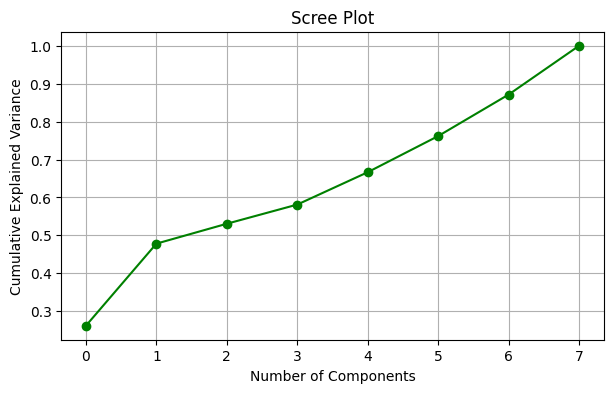

In [115]:
# Plotting the explained variance using a scree plot

plt.figure(figsize=(7,4))
plt.plot(np.cumsum(explained_variance), marker='o', color='green')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

Top 2 Principal Components (Eigenvectors): 

[[-0.1284321  -0.59378583]
 [-0.39308257 -0.17402908]
 [-0.36000261 -0.18389207]
 [-0.43982428  0.33196534]
 [-0.43502617  0.25078106]
 [-0.45194134  0.1009598 ]
 [-0.27061144  0.122069  ]
 [-0.19802707 -0.62058853]]



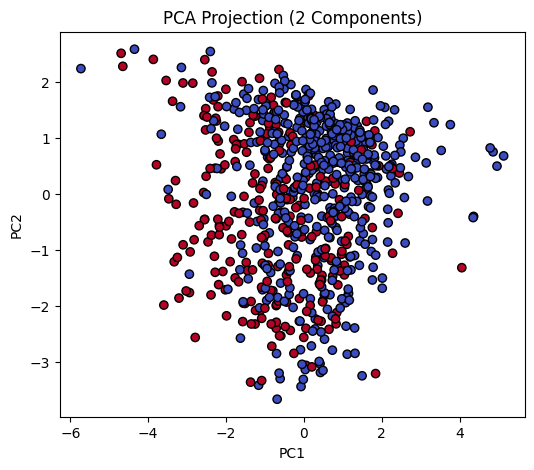

In [116]:
# Sort eigenvalues and eigenvectors in descending order

idxs = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[idxs]
eigen_vectors = eigen_vectors[:, idxs]

# Select top 2 principal components
k = 2
W = eigen_vectors[:, :k]

# Print the top 2 principal components
print("Top 2 Principal Components (Eigenvectors): \n")
print(W)
print()

# Project the data onto the top 2 principal components
X_pca = X.dot(W)

# Plotting
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', edgecolor='k')
plt.title("PCA Projection (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [117]:
# Reconstruct Original Data from Top Principal Components
X_reconstructed = X_pca.dot(W.T) # project back to original space


# Inverse standardization to get approximate original feature values
X_reconstructed_original_scale = std_scaler.inverse_transform(X_reconstructed)


print("\nThe Reconstructed Data is: \n")
transformed_data = pd.DataFrame(X_reconstructed_original_scale, columns=data.columns[:-1])

transformed_data.head(10)


The Reconstructed Data is: 



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.776337,141.181283,80.938695,21.493145,97.666603,34.815048,0.517705,44.734362
1,1.892606,102.725919,58.684156,16.555302,44.796699,28.582177,0.401031,25.278005
2,6.864545,124.788840,72.021191,9.310931,13.843005,29.311318,0.371848,43.957694
3,0.820647,99.811877,56.813732,19.440624,60.613404,29.030669,0.423281,21.372287
4,0.496861,138.378269,77.763400,48.641531,261.108044,42.131778,0.771587,22.796824
5,4.894858,107.508196,62.079666,6.047553,-16.267122,26.215400,0.309456,35.993713
6,1.227439,103.051066,58.687086,19.877802,65.196003,29.561682,0.433311,22.995291
7,4.626683,98.652899,57.179566,0.933321,-52.629382,23.656584,0.244653,34.480112
8,4.787150,160.968949,91.209550,44.941715,252.024445,43.928644,0.777168,39.150079
9,9.461086,115.617345,67.699770,-9.333921,-104.995176,22.890348,0.177412,52.346768
